Preprocessing Pipeline - API Raman Spectra
==========================================
Steps:
  1. Load & filter to 4 target compounds
  2. Spectral cropping 
  3. Cosmic ray removal  
  4. Baseline correction (arPLS algorithm via pybaselines)
  5. SNV normalisation   (Standard Normal Variate, recommended by Flanagan & Glavin 2025)
  6. Save clean spectra  → clean_spectra.csv  (ready for SVM)
  7. QC plots            → before vs after each step

Output
------
  clean_spectra.csv   — preprocessed X + label column, same format as input CSV
                        Drop into your SVM pipeline immediately.
"""

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pybaselines import Baseline

In [101]:
# =============================================================================
# 0. SETTINGS — adjust paths here
# =============================================================================
CSV_PATH   = "/Users/dons/Library/Mobile Documents/com~apple~CloudDocs/ZHAW/SS26/Track 2/Raman Solvents/raman_spectra_api_compounds.csv"
OUTPUT_CSV = "/Users/dons/Library/Mobile Documents/com~apple~CloudDocs/ZHAW/SS26/Track 2/Raman Solvents/raman_spectra_clean.csv"             # where to save clean data

TARGETS = ['Ethyl Acetate', 'Propyl acetate', 'Butyl Acetate', 'Methyl Isobutyl Ketone']
COLORS  = ['steelblue', 'darkorange', 'green', 'crimson']

# Cropping: keep only the fingerprint + C-H region
CROP_MIN = 200
CROP_MAX = 1800   # cm⁻¹

# Cosmic ray threshold: flag a point if its deviation from neighbours
# is more than COSMIC_THRESHOLD × the local standard deviation
COSMIC_THRESHOLD = 15   #lower more sensitive, higher more conservative

# ArPLS baseline: 
ARPLS_LAMBDA = 1e5    # smoothness — higher = smoother baseline, lower = follows data more closely
ARPLS_RATIO  = 1e-6   # convergence tolerance (tol) — stop when weight change falls below this
ARPLS_MAXIT  = 50     # max iterations — increase if baseline doesn't converge

In [ ]:
# 1. LOAD & FILTER

print("Loading data...")
df = pd.read_csv(CSV_PATH)
df = df[df['label'].isin(TARGETS)].reset_index(drop=True)

wavenumbers_all = df.drop(columns=['label']).columns.astype(float).values
X_raw           = df.drop(columns=['label']).values.astype(float)
y               = df['label'].values

print(f"  Loaded {X_raw.shape[0]} spectra, {X_raw.shape[1]} features")
print(f"  Wavenumber range: {wavenumbers_all[0]:.0f} – {wavenumbers_all[-1]:.0f} cm⁻¹")
print(f"  Class counts: { {g: int((y==g).sum()) for g in np.unique(y)} }")


Loading data...
  Loaded 428 spectra, 3276 features
  Wavenumber range: 150 – 3425 cm⁻¹
  Class counts: {'Butyl Acetate': 106, 'Ethyl Acetate': 110, 'Methyl Isobutyl Ketone': 105, 'Propyl acetate': 107}


In [ ]:
# 2. SPECTRAL CROPPING

print("\nCropping spectra to fingerprint region...")
crop_mask   = (wavenumbers_all >= CROP_MIN) & (wavenumbers_all <= CROP_MAX)
wavenumbers = wavenumbers_all[crop_mask]
X_cropped   = X_raw[:, crop_mask]          # ← this is what the QC plot needs
print(f"  Kept {crop_mask.sum()} wavenumbers ({CROP_MIN}–{CROP_MAX} cm⁻¹)")

# 3. COSMIC RAY REMOVAL

def remove_cosmic_rays(X, threshold=COSMIC_THRESHOLD):
    """
    Point-to-point modified Z-score cosmic ray removal.
    Detects spikes within each spectrum and replaces them with
    the median of neighbouring points.
    """
    X_cr = X.copy()
    for i in range(X_cr.shape[0]):
        diff   = np.diff(X_cr[i])
        med    = np.median(np.abs(diff - np.median(diff)))
        z      = np.abs(diff - np.median(diff)) / (med + 1e-10)
        spikes = np.where(z > threshold)[0]
        for s in spikes:
            lo = max(0, s - 2)
            hi = min(X_cr.shape[1] - 1, s + 3)
            X_cr[i, s] = np.median(X_cr[i, lo:hi])
    return X_cr

print(f"\nRemoving cosmic rays (threshold={COSMIC_THRESHOLD})...")
X_cr = remove_cosmic_rays(X_cropped)
print("  Done.")


Cropping spectra to fingerprint region...
  Kept 1601 wavenumbers (200–1800 cm⁻¹)

Removing cosmic rays (threshold=15)...
  Done.


In [ ]:

# 4. BASELINE CORRECTION — arPLS

def apply_arpls_baseline(X, wavenumbers):
    fitter    = Baseline(x_data=wavenumbers)
    X_corr    = np.zeros_like(X)
    baselines = np.zeros_like(X)

    for i in range(X.shape[0]):
        baseline, _ = fitter.arpls(X[i], lam=ARPLS_LAMBDA, 
                                         tol=ARPLS_RATIO, 
                                         max_iter=ARPLS_MAXIT)
        baselines[i] = baseline
        X_corr[i]    = X[i] - baseline

    return X_corr, baselines


print("\nApplying ArPLS baseline correction...")
X_bl, baselines = apply_arpls_baseline(X_cr, wavenumbers)
print("  Done.")


# =============================================================================
# 5. SNV NORMALISATION
# =============================================================================
# Standard Normal Variate: for each spectrum subtract its mean and divide
# by its standard deviation. This removes intensity scaling differences
# caused by slight focus variations, sample concentration, etc.

def apply_snv(X):
    means = X.mean(axis=1, keepdims=True)
    stds  = X.std(axis=1,  keepdims=True)
    stds[stds == 0] = 1   # avoid division by zero for flat spectra
    return (X - means) / stds


print("\nApplying SNV normalisation...")
X_clean = apply_snv(X_bl)
print("  Done.")


Applying ArPLS baseline correction...
  Done.

Applying SNV normalisation...
  Done.


In [105]:
# =============================================================================
# 6. SAVE CLEAN SPECTRA
# =============================================================================

df_clean = pd.DataFrame(X_clean, columns=wavenumbers.astype(int))
df_clean['label'] = y
df_clean.to_csv(OUTPUT_CSV, index=False)
print(f"\nClean spectra saved → {OUTPUT_CSV}")
print(f"  Shape: {df_clean.shape}  ({df_clean.shape[0]} spectra × {df_clean.shape[1]-1} wavenumbers + label)")


Clean spectra saved → /Users/dons/Library/Mobile Documents/com~apple~CloudDocs/ZHAW/SS26/Track 2/Raman Solvents/raman_spectra_clean.csv
  Shape: (428, 1602)  (428 spectra × 1601 wavenumbers + label)


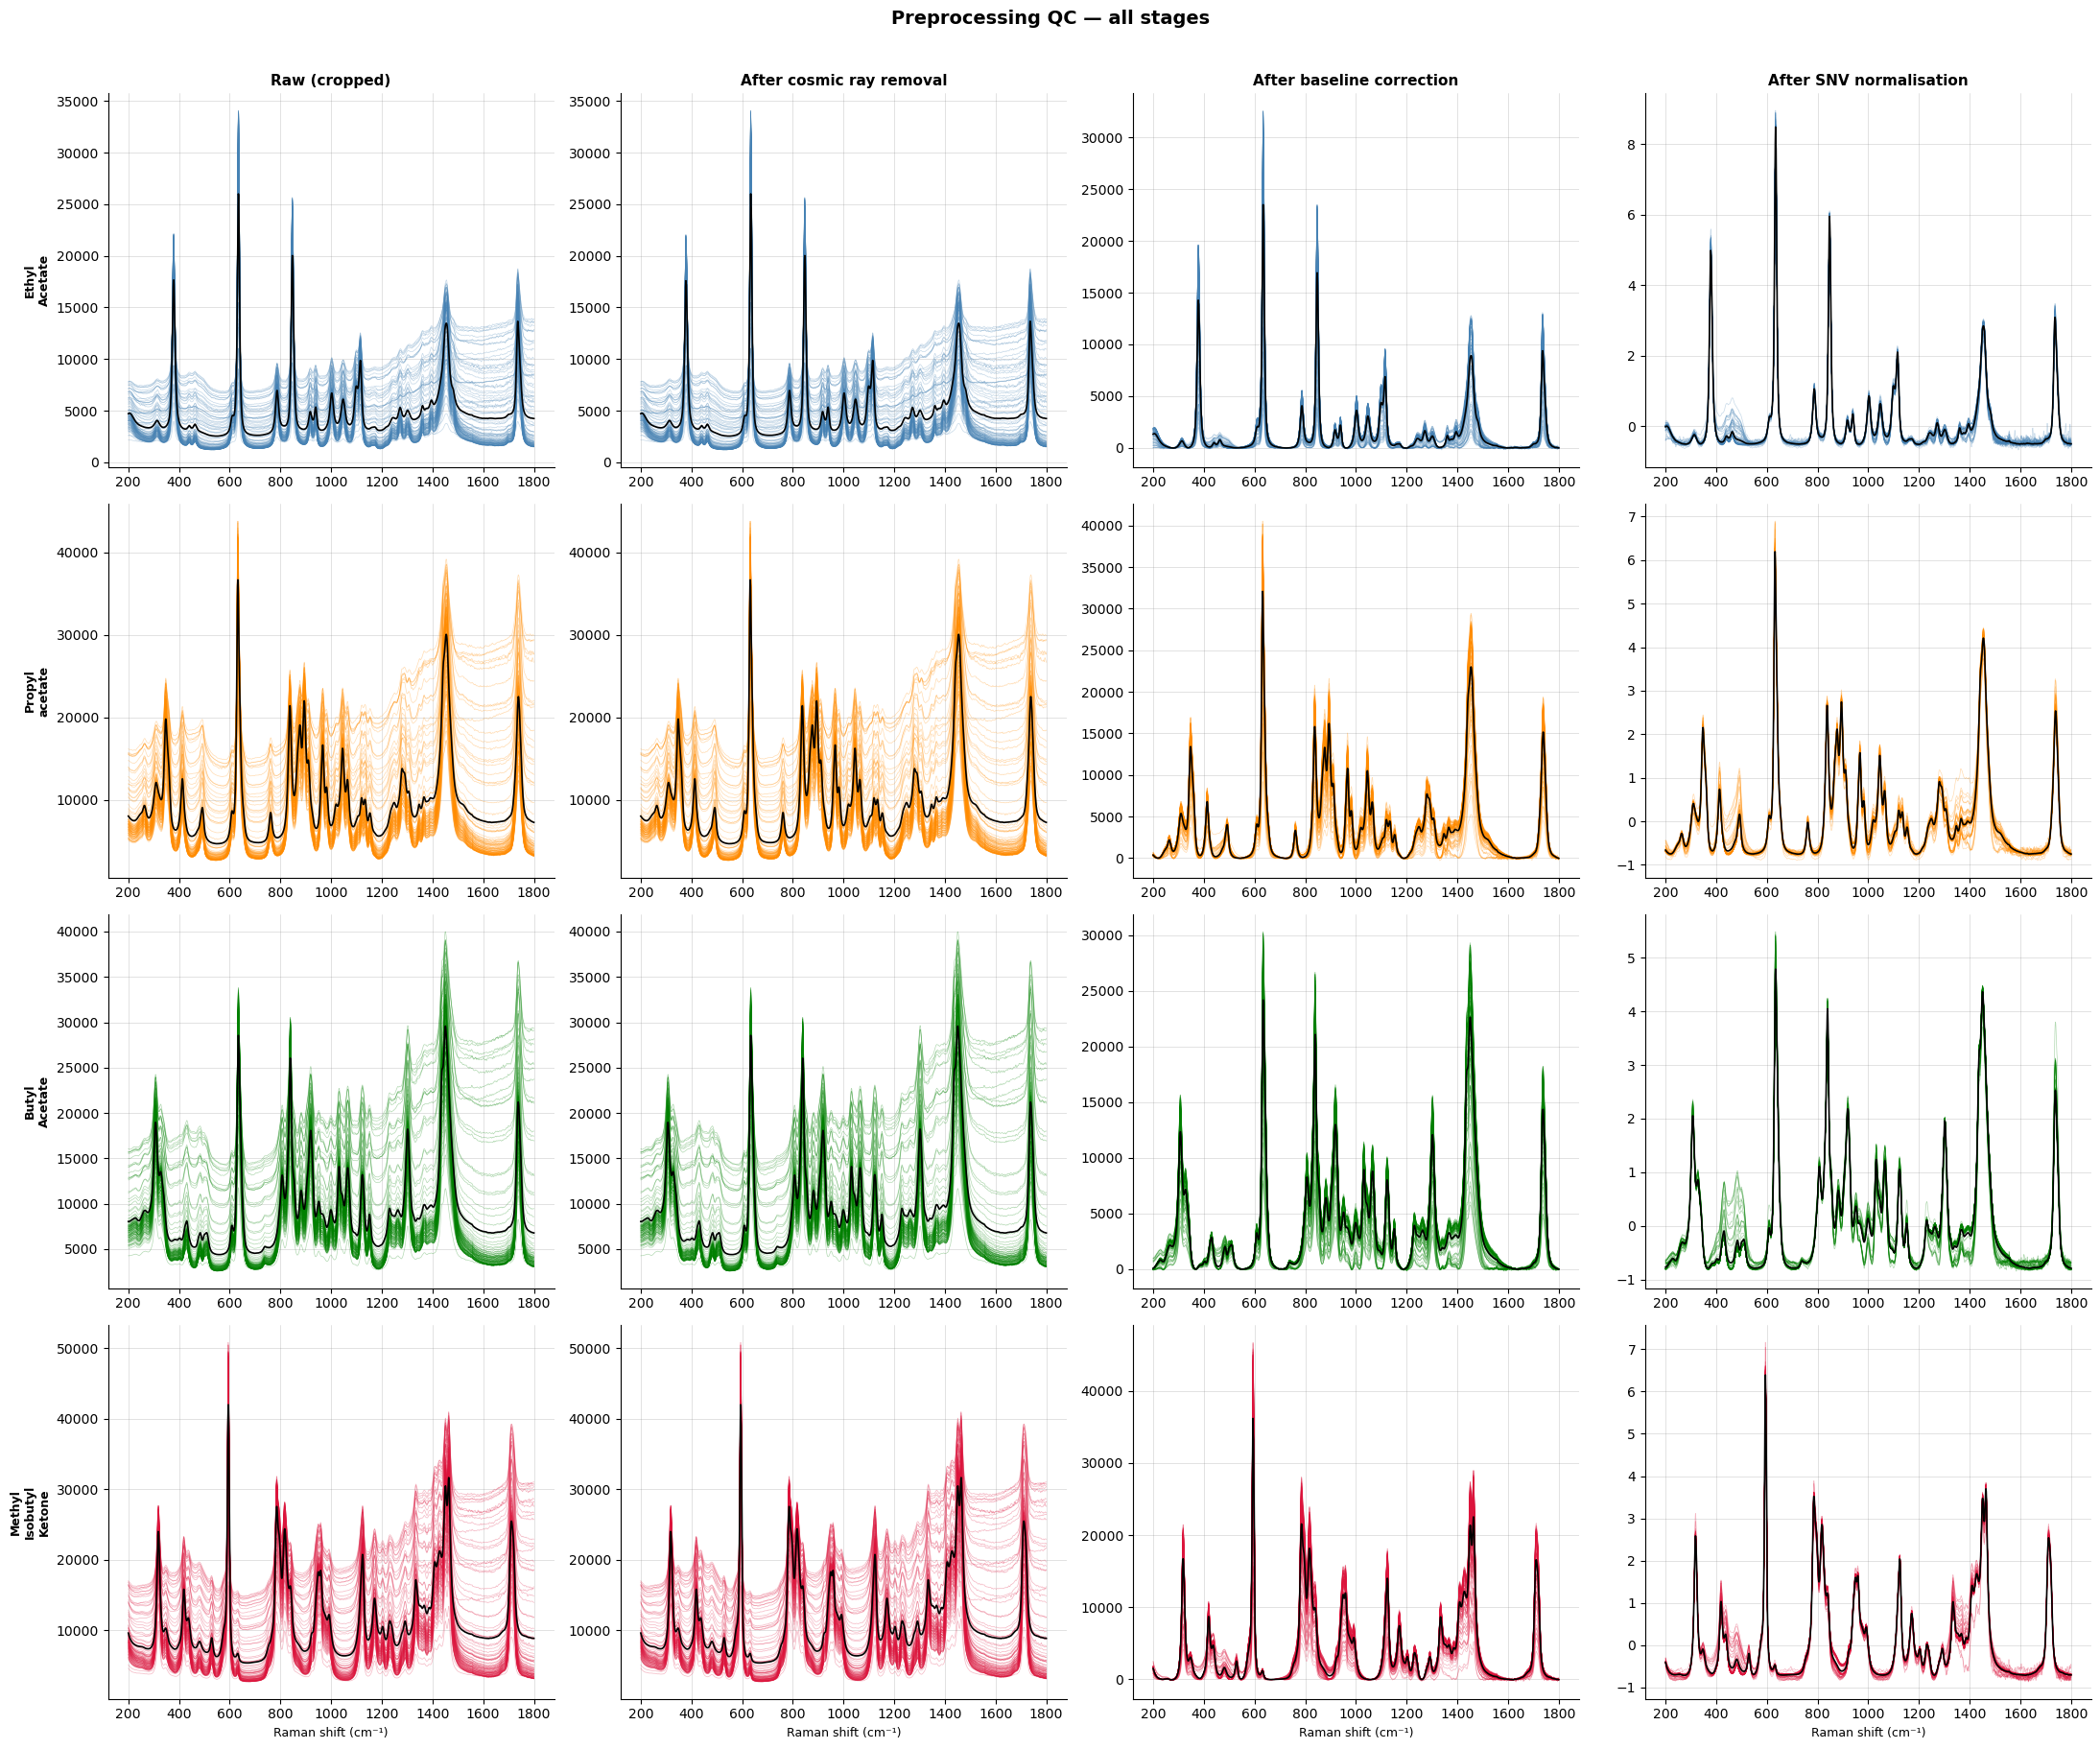

QC plot saved → preprocessing_QC.pdf


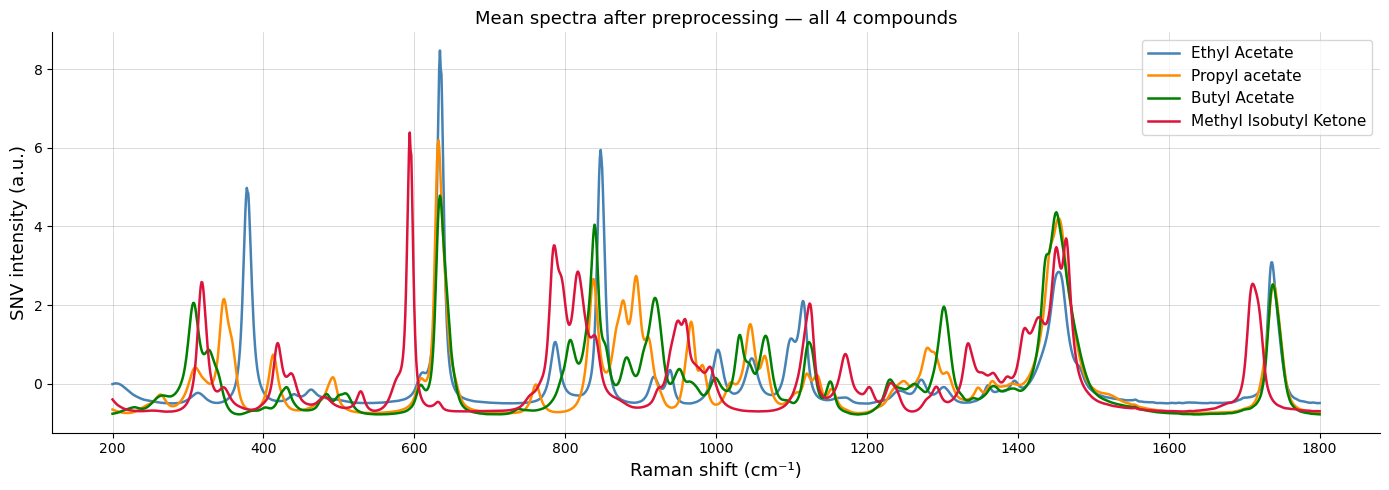

Mean spectra plot saved → mean_spectra_clean.pdf

✓ Preprocessing complete. Feed 'clean_spectra.csv' into your SVM pipeline.


In [106]:
# =============================================================================
# 7. QC PLOTS
# =============================================================================
# Plot one representative spectrum per compound at each stage

fig, axes = plt.subplots(4, 4, figsize=(22, 18))
stages      = ['Raw (cropped)', 'After cosmic ray removal', 'After baseline correction', 'After SNV normalisation']
X_stages    = [X_cropped, X_cr, X_bl, X_clean]

for col, (stage, X_stage) in enumerate(zip(stages, X_stages)):
    for row, (compound, color) in enumerate(zip(TARGETS, COLORS)):
        ax       = axes[row, col]
        mask     = y == compound
        X_subset = X_stage[mask]

        # Plot all spectra for this compound (semi-transparent)
        ax.plot(wavenumbers, X_subset.T, color=color, alpha=0.3, linewidth=0.5)
        # Overlay mean spectrum
        ax.plot(wavenumbers, X_subset.mean(axis=0), color='black', linewidth=1.2,
                label='mean')

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(visible=True, color='grey', linestyle='-', linewidth=0.4, alpha=0.4)

        if row == 0:
            ax.set_title(stage, fontsize=11, fontweight='bold')
        if col == 0:
            ax.set_ylabel(compound.replace(' ', '\n'), fontsize=9, fontweight='bold')
        if row == 3:
            ax.set_xlabel("Raman shift (cm⁻¹)", fontsize=9)

plt.suptitle("Preprocessing QC — all stages", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("preprocessing_QC.pdf", bbox_inches='tight')
plt.show()
print("QC plot saved → preprocessing_QC.pdf")


# =============================================================================
# QUICK SUMMARY: overlay all 4 compounds after preprocessing
# =============================================================================

fig, ax = plt.subplots(figsize=(14, 5))

for compound, color in zip(TARGETS, COLORS):
    mask = y == compound
    mean_spectrum = X_clean[mask].mean(axis=0)
    ax.plot(wavenumbers, mean_spectrum, color=color, linewidth=1.8, label=compound)

ax.set_xlabel("Raman shift (cm⁻¹)", fontsize=13)
ax.set_ylabel("SNV intensity (a.u.)", fontsize=13)
ax.set_title("Mean spectra after preprocessing — all 4 compounds", fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=11)
ax.grid(visible=True, color='grey', linestyle='-', linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig("mean_spectra_clean.pdf", bbox_inches='tight')
plt.show()
print("Mean spectra plot saved → mean_spectra_clean.pdf")

print("\n✓ Preprocessing complete. Feed 'clean_spectra.csv' into your SVM pipeline.")